In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [6]:
data = pd.read_csv("../data/wbes_sintetico.csv")

cols = [
    "sales_annual_usd",
    "employees",
    "training",
    "access_finance",
    "exporter",
    "competition_level",
]

df = data[cols].dropna().copy()


In [9]:
df.shape

(1068, 6)

In [10]:
df.head()

,sales_annual_usd,employees,training,access_finance,exporter,competition_level
0,42879.327130,13.0,1.0,1.0,0,Media
1,54570.897174,9.0,0.0,0.0,0,Baja
2,56311.260030,15.0,0.0,0.0,1,Baja
3,93419.359675,25.0,1.0,0.0,1,Baja
4,24608.889361,9.0,0.0,0.0,0,Baja


In [11]:
mean_sales = df["sales_annual_usd"].mean()
df["successful"] = (df["sales_annual_usd"] > mean_sales).astype(int)

In [12]:
map_comp = {"Baja": 0, "Media": 1, "Alta": 2}
df["competition_level"] = df["competition_level"].map(map_comp)

In [13]:
df = df.dropna().copy()

In [14]:
X = df[["employees", "training", "exporter", "access_finance", "competition_level"]]
y = df["successful"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [17]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("Matriz de confusión:\n", cm)
print("AUC:", auc)


Accuracy: 0.7320872274143302
Matriz de confusión:
 [[168  26]
 [ 60  67]]
AUC: 0.8216170143680495


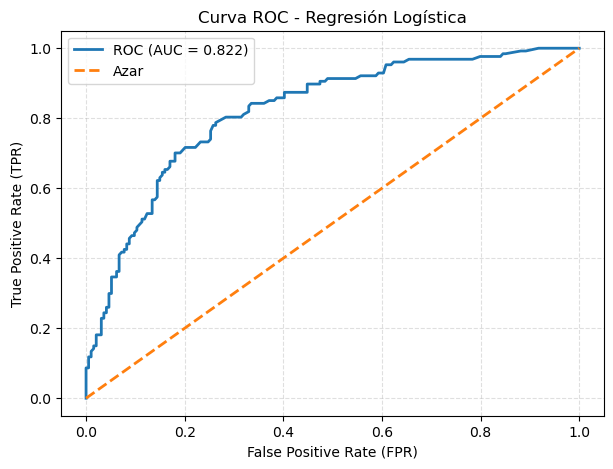

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", linewidth=2, label="Azar")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# Analisis de los Resultados

Con la información analizada, sí se puede clasificar si una empresa es “exitosa” según sus características, porque el modelo separa bien ambos grupos. Esto se ve en la curva ROC, donde la línea está por encima del azar, y en el AUC = 0.822, lo que indica un desempeño bueno para distinguir empresas exitosas y no exitosas.

Basándonos en los resultados, podemos definir cuáles son los patrones que predicen el éxito y el fracaso de una empresa a partir de los coeficientes del modelo. Si una variable tiene coeficiente positivo, incrementa la probabilidad de que la empresa sea clasificada como exitosa; si es negativo, la reduce. Además, las variables con mayor magnitud son las que más influyen en la decisión del modelo, por lo que representan los factores más relevantes asociados al éxito o al fracaso.